In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plotsettings import *
import limpy.theory as lt

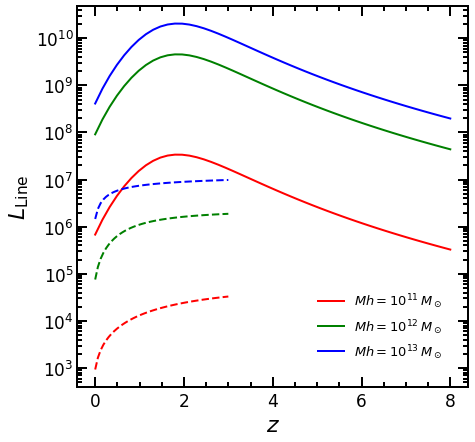

In [2]:
# Plot L_CII for different halo mass and redshift using LCII-Mhalo fitting formula
z=np.linspace(0, 8, num=50)
z_co=np.linspace(0, 3, num=50)

#for CII(J=1-0)
l_cii11=lt.mhalo_to_lline(10**11,z, line_name='CII')
l_cii12=lt.mhalo_to_lline(10**12,z, line_name='CII')
l_cii13=lt.mhalo_to_lline(10**13,z, line_name='CII')

#for CO(J=1-0)
l_co11=lt.mhalo_to_lline(10**11,z_co, line_name='CO10')
l_co12=lt.mhalo_to_lline(10**12,z_co, line_name='CO10')
l_co13=lt.mhalo_to_lline(10**13,z_co, line_name='CO10')


lw=2.0
plt.plot(z, l_cii11, lw=lw, color="r", label=r'$Mh=10^{11}\,M_\odot$')
plt.plot(z, l_cii12, lw=lw, color="g", label=r'$Mh=10^{12}\,M_\odot$')
plt.plot(z, l_cii13, lw=lw, color="b", label=r'$Mh=10^{13}\,M_\odot$')

plt.plot(z_co, l_co11, lw=lw, ls='--', color="r")
plt.plot(z_co, l_co12, lw=lw, ls='--',color="g")
plt.plot(z_co, l_co13, lw=lw, ls='--',color="b")

plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$L_{\rm Line}$')
plt.legend(loc=0, frameon=False)

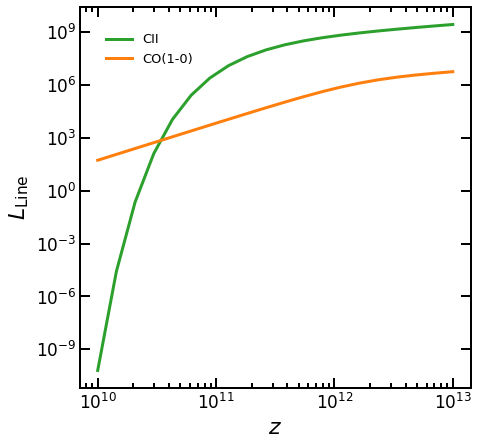

In [3]:
z=0.5
m=np.logspace(10,13,num=20)
l_ciim=lt.mhalo_to_lline(m,z, line_name='CII')
l_co10m=lt.mhalo_to_lline(m,z, line_name='CO10')

plt.plot(m,l_ciim,lw=3,color='C2', label='CII')
plt.plot(m,l_co10m,lw=3,color='C1', label='CO(1-0)')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$L_{\rm Line}$')
plt.legend(loc=0, frameon=False)

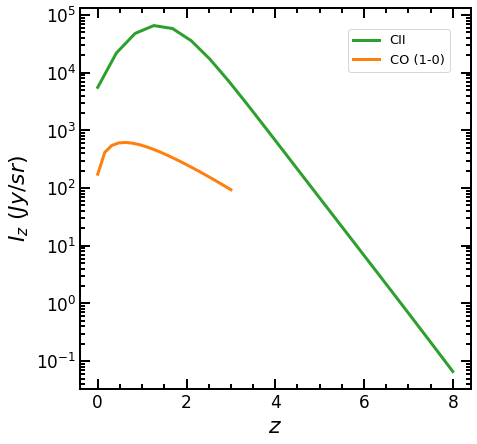

In [4]:
# Plot average intensity of CII and CO lines
z=np.linspace(0, 8, num=20)
z_co=np.linspace(0, 3, num=20)

nu_rest_CII=1900
nu_rest_CO10=115 #Ghz

Icii=[lt.I_line(zz, line_name='CII') for zz in z]
ICO10=Iav=[lt.I_line(z1, line_name='CO10') for z1 in z_co]
plt.plot(z, Icii, lw=3.0, color='C2',label="CII")
plt.plot(z_co, ICO10, lw=3.0, color='C1',label="CO (1-0)")

plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$I_z\,\,(Jy/sr)$')
plt.legend(loc=0)

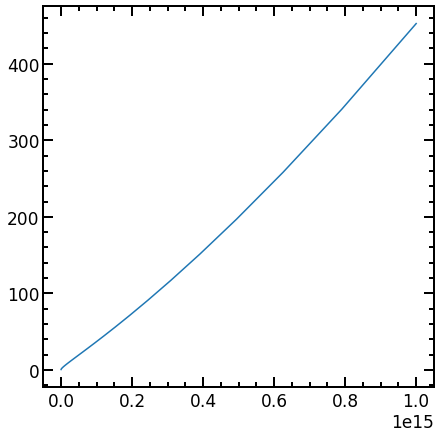

In [5]:
z=1.0
m=np.logspace(10,15)
b=lt.bias_dm(m,z)
plt.plot(m,b)


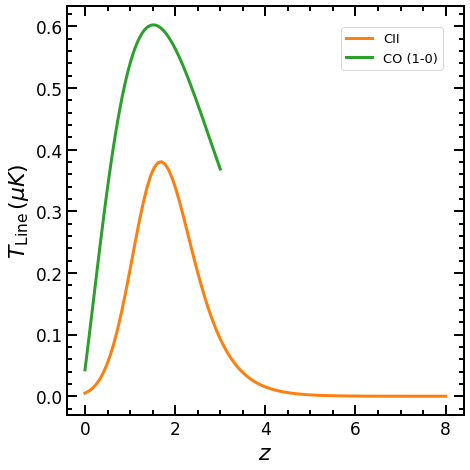

In [6]:
z=np.linspace(0, 8, num=100)
z_co=np.linspace(0, 3, num=100)

# Plot T_line for CII and CO lines
T_cii=[lt.T_line(zz,line_name="CII",fduty=0.1)*1e6 for zz in z]
T_co10=[lt.T_line(zz,line_name="CO10",fduty=0.1)*1e6 for zz in z_co]

plt.plot(z, T_cii, lw=3.0, color='C1',label="CII")
plt.plot(z_co, T_co10, lw=3.0, color='C2',label="CO (1-0)")

#plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$T_{\rm Line}\,(\mu K)$')
plt.legend(loc=0)
plt.tight_layout()
plt.savefig("temperature.png")

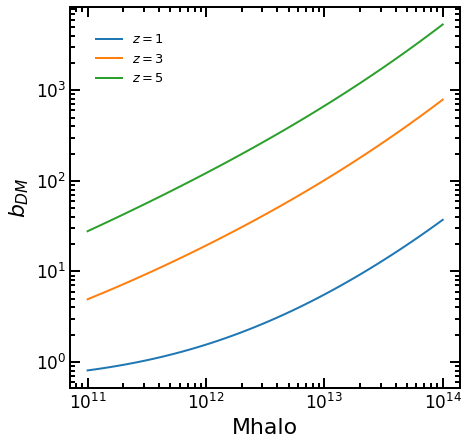

In [7]:
# plot Dark matter bias
m=np.logspace(11, 14)
pz1=lt.bias_dm(m,1.0)
pz3=lt.bias_dm(m,3.0)
pz5=lt.bias_dm(m,5.0)

plt.plot(m,pz1,lw=lw,label=r'$z=1$')
plt.plot(m,pz3,lw=lw,label=r'$z=3$')
plt.plot(m,pz5,lw=lw,label=r'$z=5$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mhalo')
plt.ylabel(r'$b_{DM}$')
plt.legend(loc=0, frameon=False)

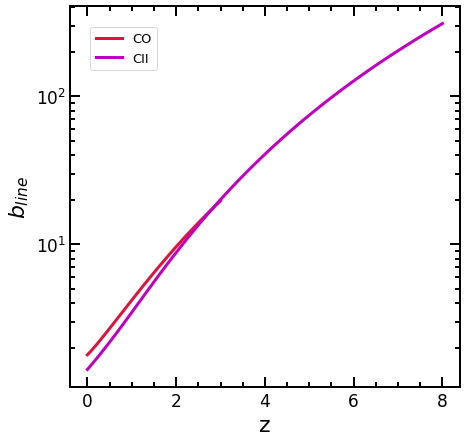

In [8]:
# plot bias of CII lines
z_c2=np.linspace(0, 8, num=50)
z_co=np.linspace(0, 3, num=50)

bline_co=[lt.b_line(zz, line_name='CO10') for zz in z_co]
bline_c2=[lt.b_line(zz, line_name='CII') for zz in z_c2]

plt.plot(z_co,bline_co,lw=3, color='crimson',label="CO")
plt.plot(z_c2,bline_c2,lw=3, color='m',label="CII")
plt.yscale('log')
plt.xlabel('z')
plt.ylabel(r'$b_{line}$')
plt.legend(loc=0)

In [9]:
# plot all the power spectra
zline=3.0
nu_rest_cii=1900 #GhZ
k=np.logspace(-3, 2, num=20)
pkshot_cii=lt.Pk_line(k,zline,line_name='CII', label='shot')
pkclus_cii=lt.Pk_line(k,zline,line_name='CII', label='clustering') 
pktotal_cii=lt.Pk_line(k,zline,line_name='CII', label='total')

In [10]:
# plot all the power spectra
zline=3.0
nu_rest_co=115 #GhZ
line_name='CO10'
pkshot_co=lt.Pk_line(k,zline,fduty=1.0,line_name=line_name, label='shot') 
pkclus_co=lt.Pk_line(k,zline,fduty=1.0,line_name=line_name,  label='clustering') 
pktotal_co=lt.Pk_line(k,zline,fduty=1.0,line_name=line_name,  label='total') 

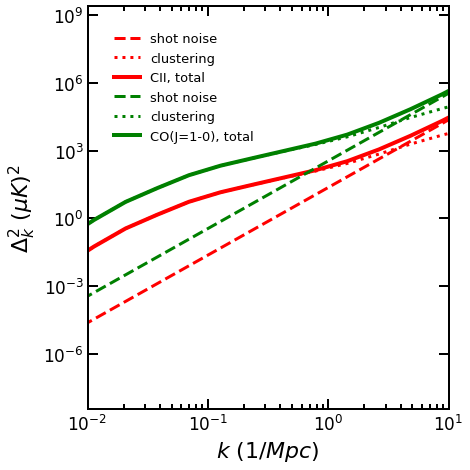

In [11]:

plt.plot(k, pkshot_cii*1e12, lw=3, ls='--', color='r', label="shot noise")
plt.plot(k, pkclus_cii*1e12, lw=3, ls=':', color='r',label="clustering")
plt.plot(k, pktotal_cii*1e12, lw=4, color='r',label="CII, total")

plt.plot(k, pkshot_co*1e12, lw=3, ls='--', color='g', label="shot noise")
plt.plot(k, pkclus_co*1e12, lw=3, ls=':', color='g',label="clustering")
plt.plot(k, pktotal_co*1e12, lw=4, color='g',label="CO(J=1-0), total")

plt.ylabel(r'$\Delta^2_k\,\,(\mu K)^2$')
plt.xlabel(r'$k\,\,(1/Mpc)$')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=0, frameon=False)
plt.xlim(1e-2,1e1)
plt.tight_layout()
plt.savefig("pk_lines.png")

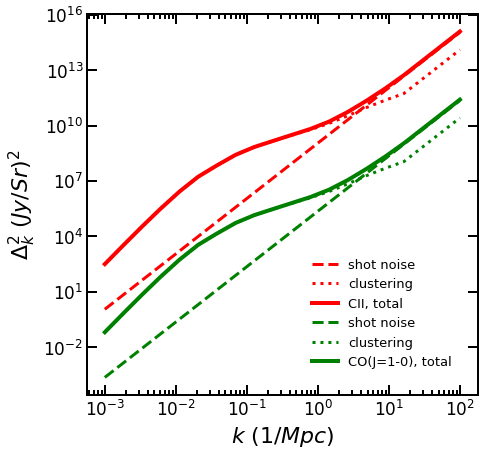

In [12]:
# Do it for intensity unit
zline=3.0
nu_rest_cii=1900 #GhZ
k=np.logspace(-3, 2, num=20)
line_name='CII'
pkshot_cii=lt.Pk_line(k,zline,nu_rest_cii,line_name=line_name,label='shot',pk_unit='intensity')
pkclus_cii=lt.Pk_line(k,zline,nu_rest_cii,line_name=line_name,label='clustering',pk_unit='intensity') 
pktotal_cii=lt.Pk_line(k,zline,nu_rest_cii,line_name=line_name,label='total',pk_unit='intensity')

nu_rest_co=115 #GhZ
line_name='CO10'
pkshot_co=lt.Pk_line(k,zline,nu_rest_co,line_name=line_name,label='shot',pk_unit='intensity') 
pkclus_co=lt.Pk_line(k,zline,nu_rest_co,line_name=line_name,label='clustering',pk_unit='intensity') 
pktotal_co=lt.Pk_line(k,zline,nu_rest_co,line_name=line_name,label='total',pk_unit='intensity') 

plt.plot(k, pkshot_cii, lw=3, ls='--', color='r', label="shot noise")
plt.plot(k, pkclus_cii, lw=3, ls=':', color='r',label="clustering")
plt.plot(k, pktotal_cii, lw=4, color='r',label="CII, total")
plt.plot(k, pkshot_co, lw=3, ls='--', color='g', label="shot noise")
plt.plot(k, pkclus_co, lw=3, ls=':', color='g',label="clustering")
plt.plot(k, pktotal_co, lw=4, color='g',label="CO(J=1-0), total")

plt.ylabel(r'$\Delta^2_k\,\,(Jy/Sr)^2$')
plt.xlabel(r'$k\,\,(1/Mpc)$')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=0, frameon=False)


In [13]:
ell=np.linspace(0,10000,num=10001)

In [14]:
z=3
deltaz=0.03
cl_cii=lt.Cl_line(ell, z, deltaz, fduty=1.0,line_name='CII')
cl_co=lt.Cl_line(ell, z, deltaz, fduty=1.0,line_name='CO10')

/Users/anirbanroy/opt/anaconda3/lib/python3.7/site-packages/camb/results.py:946: RuntimeWarning: divide by zero encountered in log
  return self.logsign * np.exp(self(z, np.log(kh), grid=grid))
/Users/anirbanroy/opt/anaconda3/lib/python3.7/site-packages/limpy-1.0-py3.7.egg/limpy/theory.py:329: RuntimeWarning: invalid value encountered in true_divide
  pk=dk*2*np.pi**2/kp**3


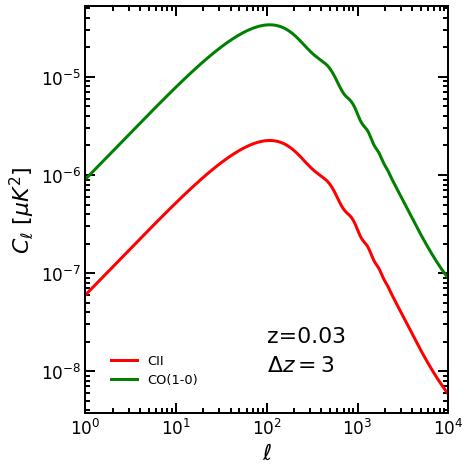

In [15]:
plt.loglog(ell,cl_cii*1e12,lw=3, color='r', label='CII')
plt.loglog(ell,cl_co*1e12,lw=3, color='g', label='CO(1-0)')
plt.legend(loc=0, frameon=False)
plt.xlim(1,1e4)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell\,\,[\mu K^2]$")
plt.annotate("z=0.03", xy=(100,2e-8))
plt.annotate(r"$\Delta z=3$", xy=(100,1e-8))
plt.savefig("cl_line.png")
plt.tight_layout()

In [22]:
import healpy as hp
np.random.seed(11)
map_cii=hp.synfast(cl_cii,nside=512)

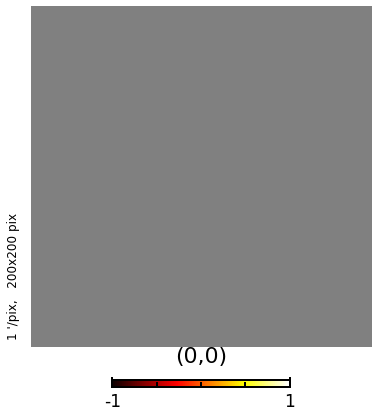

In [24]:
import matplotlib.colors as colors
hp.gnomview(map_cii, reso=1, title='',cmap=plt.cm.get_cmap('hot'))
plt.savefig("map_CII.png")

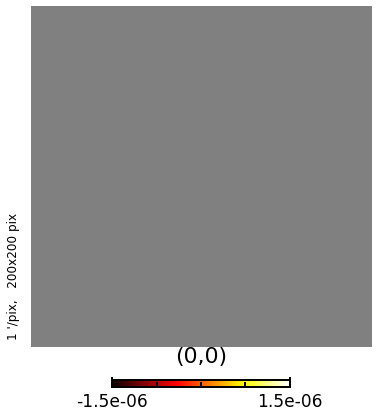

In [25]:
np.random.seed(11)
import healpy as hp
map_co=hp.synfast(cl_co,nside=2048)
hp.gnomview(map_co, reso=1,min=-1.5e-6, max=1.5e-6, title='',cmap=plt.cm.get_cmap('hot'))
plt.savefig("map_CO.png")

In [26]:
import limpy.utils as lu

In [29]:
# Do it for intensity unit
zline=7.0
nu_rest_cii=1900 #GhZ
k=np.logspace(-3, 2, num=20)
line_name='CII'
dktotal_cii=lt.Pk_line(k,zline,nu_rest_cii,line_name=line_name,label='total',pk_unit='intensity')

pk_line=dktotal_cii*2*np.pi**2/k**3

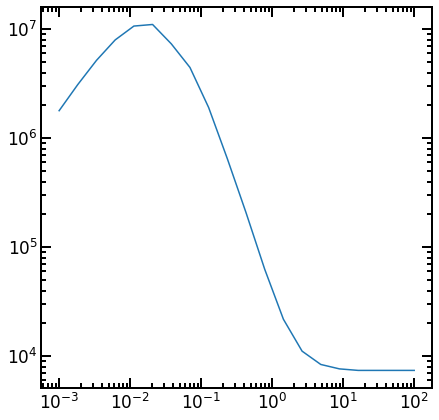

In [31]:
plt.loglog(k, pk_line)

In [33]:
Nm=lu.N_modes(k,7, 1, 16, 20, line_name='CII' )

In [35]:
varCII=(pk_line+lu.P_noise_ccatp())**2/Nm

In [55]:
SNR=pk_line/np.sqrt(varCII)
SNR

array([0.00134024, 0.00426866, 0.01302254, 0.03669635, 0.08998008,
       0.17052858, 0.20811176, 0.2318695 , 0.18251029, 0.11360186,
       0.06664631, 0.03694699, 0.02356696, 0.02201019, 0.03046213,
       0.05086072, 0.09028242, 0.16548594, 0.30333254, 0.55600269])

In [192]:
def SNR_line(k,z, delta_lnk, A_s, B_nu, line_name='CII'):
    delta_k=k*10**(delta_lnk)
    
    Nm=lu.N_modes(k,z, delta_k, A_s, B_nu, line_name='CII' )
    dktotal_cii=lt.Pk_line(k,zline,line_name=line_name,label='total',pk_unit='intensity')

    pk_line=dktotal_cii*2*np.pi**2/k**3
    
    varCII=((pk_line+lu.P_noise_ccatp())**2)/Nm
    
    SNR=pk_line/np.sqrt(varCII)
    return SNR


def delta_pk_line(k,z, delta_lnk, A_s, B_nu, line_name='CII'):
    delta_k=k*10**(delta_lnk)
    
    Nm=lu.N_modes(k,z, delta_k, A_s, B_nu, line_name='CII' )
    dktotal_cii=lt.Pk_line(k,zline,line_name=line_name,label='total',pk_unit='intensity')

    pk_line=dktotal_cii*2*np.pi**2/k**3
    
    varCII=((pk_line+lu.P_noise_ccatp())**2)/Nm
    return np.sqrt(varCII)


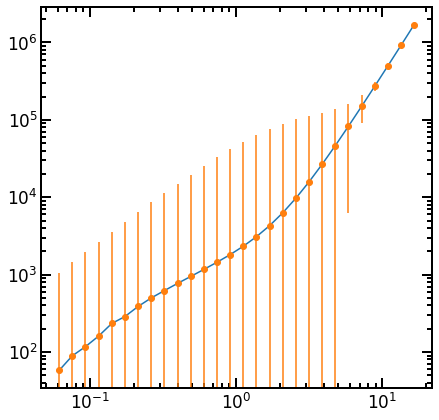

In [196]:

def k_binning(kmin, kmax, ln_deltak):
    bins=(np.log10(kmax)-np.log10(kmin))/ln_deltak
    kk=np.zeros(int(bins))
    delta=np.zeros(int(bins))
    for j in range(int(bins)):
        kk[j]=(kmin*10**(ln_deltak*(j)))
    
    delta_k=np.diff(kk)
    
    k_center=(kk[:-1]+delta_k)/2
    return k_center, delta_k
    
k_center, delta_k=k_binning(1e-1, 5e1, ln_deltak=0.09)


snr=SNR_line(k_center,7, delta_lnk=delta_k, A_s=16, B_nu=20, line_name='CII')

delta_pk=delta_pk_line(k_center,7, delta_lnk=delta_k, A_s=16, B_nu=20, line_name='CII')

delta_dk=k_center**3*delta_pk/(2*np.pi**2)

dktotal_cii=lt.Pk_line(k_center,zline,line_name=line_name,label='total',pk_unit='intensity')
pktotal_cii=dktotal_cii*2*np.pi**2/k_center**3


plt.plot(k_center, dktotal_cii)
plt.errorbar(k_center, dktotal_cii, yerr=delta_dk, fmt='o' )
plt.yscale('log')
plt.xscale('log')

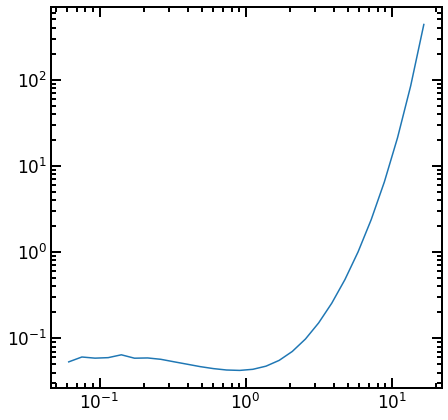

In [183]:
plt.loglog(k_center,snr)

In [89]:
p=(np.log10(10**2)-np.log10(10**-2))/0.05

In [154]:
dktotal_cii

array([2.27901641e+00, 3.59283512e+01, 2.55569579e+02, 9.67253793e+02,
       3.82287685e+03, 5.27966117e+04, 1.48521318e+06])

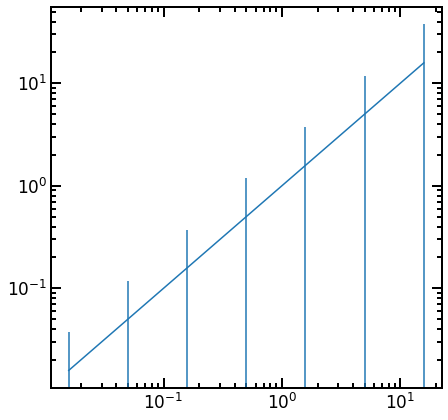

In [142]:
kmax=1e2
kmin=1e-2
k=np.linspace(10**-2,10**2)
deltak=0.5
bins=(np.log10(kmax)-np.log10(kmin))/deltak
kk=np.zeros(int(bins))
delta=np.zeros(int(bins))
for j in range(int(bins)):
    kk[j]=(kmin*10**(deltak*(j)))
    
    
delta_k=np.diff(kk)
    
k_center=(kk[:-1]+delta_k)/2




#plt.scatter(kk,kk)
plt.errorbar(k_center,k_center, yerr=delta_k)
plt.xscale('log')
plt.yscale('log')

array([ 0.02162278,  0.06837722,  0.21622777,  0.68377223,  2.16227766,
        6.83772234, 21.6227766 ])

In [108]:
kk[2]-kk[1]   

0.0683772233983162

In [110]:
np.diff(kk)

array([ 0.02162278,  0.06837722,  0.21622777,  0.68377223,  2.16227766,
        6.83772234, 21.6227766 ])

In [111]:
kk

array([1.00000000e-02, 3.16227766e-02, 1.00000000e-01, 3.16227766e-01,
       1.00000000e+00, 3.16227766e+00, 1.00000000e+01, 3.16227766e+01])